# Week 4: Cats vs Dogs Classification using Transfer Learning

## Project Overview

This project uses Transfer Learning with MobileNetV2, a pretrained convolutional neural network trained on the ImageNet dataset, to classify images of cats and dogs.

## Objectives

* Load and preprocess the Cats vs Dogs dataset from TensorFlow Datasets.
* Apply data augmentation to improve model generalization.
* Use MobileNetV2 as a frozen feature extractor.
* Train a custom classification head for binary image classification.
* Achieve more than 95% validation accuracy.
* Save the trained model weights for future fine-tuning.

## Model Architecture

Input Image (160 × 160 × 3)
→ Data Augmentation (RandomFlip, RandomRotation)
→ MobileNetV2 Preprocessing
→ MobileNetV2 (Frozen)
→ GlobalAveragePooling2D
→ Dropout (0.2)
→ Dense (1, Sigmoid)
→ Cat / Dog Prediction

## Technologies Used

* Python
* TensorFlow
* TensorFlow Datasets (TFDS)
* MobileNetV2
* Google Colab / Jupyter Notebook
* Matplotlib

## Expected Outcome

Train a high-accuracy image classifier using transfer learning and demonstrate the effectiveness of pretrained deep learning models for computer vision tasks.


In [3]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [4]:
(train_ds, val_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

In [5]:
IMG_SIZE = (160, 160)

def resize(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    return image, label

train_ds = train_ds.map(resize)
val_ds = val_ds.map(resize)

In [6]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.batch(32).prefetch(AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(AUTOTUNE)

In [7]:
base = tf.keras.applications.MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights="imagenet"
)

base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
inputs = tf.keras.Input(shape=(160, 160, 3))

x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.9816 - loss: 0.0505 - val_accuracy: 0.9854 - val_loss: 0.0437
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.9847 - loss: 0.0437 - val_accuracy: 0.9856 - val_loss: 0.0427
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9849 - loss: 0.0412 - val_accuracy: 0.9845 - val_loss: 0.0436
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.9850 - loss: 0.0415 - val_accuracy: 0.9847 - val_loss: 0.0443
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9864 - loss: 0.0379 - val_accuracy: 0.9839 - val_loss: 0.0438
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 52ms/step - accuracy: 0.9869 - loss: 0.0371 - val_accuracy: 0.9837 - val_loss: 0.0462
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 29s 50ms/step - accuracy: 0.9869 - loss: 0.0358 - val_accuracy: 0.9832 - val_loss: 0.0456
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 58ms/step - accuracy: 0.9872 - loss: 0.0359 - 

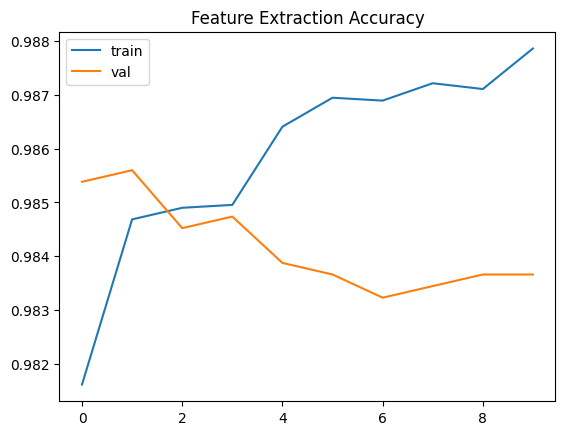

In [12]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.title("Feature Extraction Accuracy")
plt.show()

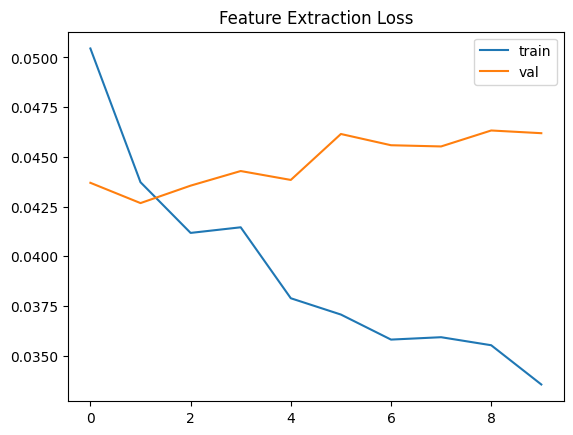

In [13]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.legend()
plt.title("Feature Extraction Loss")
plt.show()

In [15]:
model.save("cats_dogs_feature_extraction.keras")

In [17]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9837 - loss: 0.0462
Validation Accuracy: 0.9836629629135132


In [18]:
import os
print(os.listdir())

['.config', 'cats_dogs_feature_extraction.keras', 'cats_dogs_feature_extraction.h5', 'sample_data']


In [19]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/cats_dogs_feature_extraction.keras")

Mounted at /content/drive


# Cats vs Dogs — Fine-Tuning Phase (Transfer Learning)

## Today's Goal
In this phase, we improve the previously trained feature extraction model by unfreezing the top layers of the MobileNetV2 base model and fine-tuning it with a very small learning rate (1e-5). This allows the pretrained model to adapt slightly to the Cats vs Dogs dataset without destroying learned ImageNet features.

---

## Steps Followed

1. Loaded the previously saved feature extraction model (`cats_dogs_feature_extraction.keras`).
2. Retrieved the MobileNetV2 base model from the architecture.
3. Unfroze only the last ~30 layers of the base model while keeping earlier layers frozen.
4. Recompiled the model using a very small learning rate (`1e-5`) to avoid disrupting pretrained weights.
5. Trained the model for additional epochs on the same dataset.
6. Monitored training and validation accuracy to evaluate improvement over feature extraction phase.
7. Saved the final fine-tuned model as `cats_dogs_finetuned.keras`.

---

## Key Concept
Fine-tuning allows the pretrained model to adjust high-level features to better fit the target dataset. This step usually improves accuracy beyond the feature extraction stage.

---

## Expected Outcome
- Higher validation accuracy than feature extraction phase (~95% → ~97–98%)
- Better generalization on unseen images
- Slight reduction in training-validation gap

In [20]:
import tensorflow as tf

model = tf.keras.models.load_model("cats_dogs_feature_extraction.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 4 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
base_model = model.layers[1]  # sometimes index may differ, adjust if needed

base_model.trainable = True

In [22]:
for layer in base_model.layers:
    layer.trainable = False

In [23]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

In [24]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # VERY SMALL LR
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [25]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 74s 93ms/step - accuracy: 0.9529 - loss: 0.1238 - val_accuracy: 0.9774 - val_loss: 0.0758
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 55ms/step - accuracy: 0.9769 - loss: 0.0615 - val_accuracy: 0.9815 - val_loss: 0.0604
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 45s 61ms/step - accuracy: 0.9861 - loss: 0.0388 - val_accuracy: 0.9830 - val_loss: 0.0569
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.9918 - loss: 0.0245 - val_accuracy: 0.9822 - val_loss: 0.0562
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.9959 - loss: 0.0165 - val_accuracy: 0.9824 - val_loss: 0.0556
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - accuracy: 0.9987 - loss: 0.0104 - val_accuracy: 0.9826 - val_loss: 0.0569
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 33s 56ms/step - accuracy: 0.9990 - loss: 0.0073 - val_accuracy: 0.9819 - val_loss: 0.0576
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 53ms/step - accuracy: 0.9994 - loss: 0.0048 - 

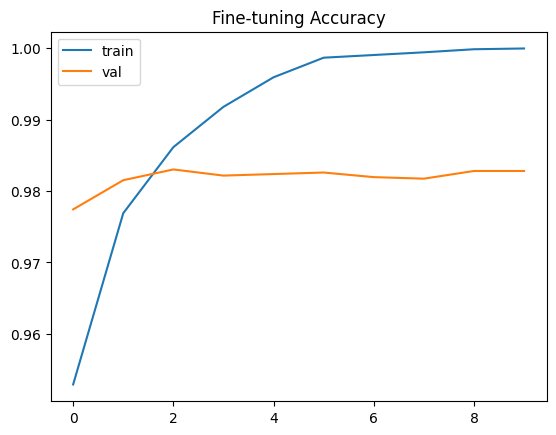

In [26]:
import matplotlib.pyplot as plt

plt.plot(history_fine.history["accuracy"], label="train")
plt.plot(history_fine.history["val_accuracy"], label="val")
plt.legend()
plt.title("Fine-tuning Accuracy")
plt.show()

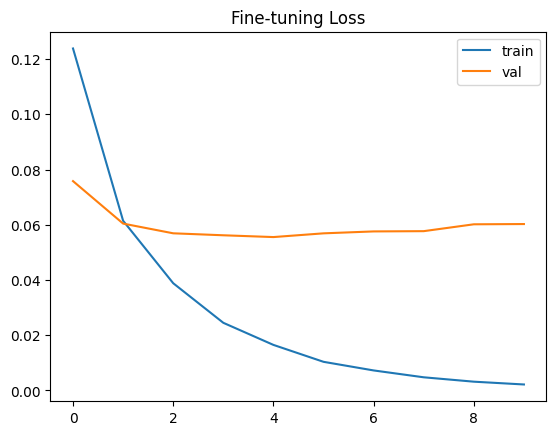

In [27]:
plt.plot(history_fine.history["loss"], label="train")
plt.plot(history_fine.history["val_loss"], label="val")
plt.legend()
plt.title("Fine-tuning Loss")
plt.show()

In [28]:
loss, acc = model.evaluate(val_ds)
print("Final Validation Accuracy:", acc)

146/146 ━━━━━━━━━━━━━━━━━━━━ 9s 62ms/step - accuracy: 0.9828 - loss: 0.0603
Final Validation Accuracy: 0.9828031063079834


In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━

In [30]:
import matplotlib.pyplot as plt

wrong_images = []
wrong_labels = []
wrong_preds = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    for i in range(len(labels)):
        if preds[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_labels.append(labels[i].numpy())
            wrong_preds.append(preds[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
